In [1]:
!pip install numpy
!pip install pandas

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch_geometric.nn import GATConv
from torch_geometric.data import Data

In [6]:
import numpy as np  # Linear algebra
import pandas as pd  # Data processing, CSV file I/O
import os

# Specify the file path
filename = "ind_nifty500list_filtered_final.csv"  # Replace with the actual file path

# Check if the file exists
if os.path.exists(filename):
    print(f"\nUsing file: {filename}")
    
    # Load CSV into a DataFrame
    df = pd.read_csv(filename)
    
    # Display first few rows
    print("\nFirst 5 rows of the dataset:")
    print(df.head())
else:
    print(f"\nError: File '{filename}' not found. Please check the file path.")




Using file: ind_nifty500list_filtered_final.csv

First 5 rows of the dataset:
            Company Name                Industry     Symbol Series  \
0       360 ONE WAM Ltd.      Financial Services     360ONE     EQ   
1         ABB India Ltd.           Capital Goods        ABB     EQ   
2               ACC Ltd.  Construction Materials        ACC     EQ   
3   AIA Engineering Ltd.           Capital Goods     AIAENG     EQ   
4  APL Apollo Tubes Ltd.           Capital Goods  APLAPOLLO     EQ   

      ISIN Code  
0  INE466L01038  
1  INE117A01022  
2  INE012A01025  
3  INE212H01026  
4  INE702C01027  


In [7]:
#pip install yfinance

In [8]:
import yfinance as yf

ticker = "ONGC.NS"
start_date, end_date = "2020-01-10", "2025-01-10"
data = yf.download(ticker, start=start_date, end=end_date)
print(data.head())  # Print first few rows
print(data.columns)  # Check column names


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker        ONGC.NS    ONGC.NS    ONGC.NS    ONGC.NS   ONGC.NS
Date                                                            
2020-01-10  87.661972  88.403371  87.344225  87.873798   6550218
2020-01-13  88.579895  88.756419  87.732581  87.732581   5737187
2020-01-14  88.297455  88.721112  87.414833  88.579889  12432511
2020-01-15  88.015007  88.615188  87.732567  88.297447   5714614
2020-01-16  87.909096  88.403362  87.591354  88.262144   7322878
MultiIndex([( 'Close', 'ONGC.NS'),
            (  'High', 'ONGC.NS'),
            (   'Low', 'ONGC.NS'),
            (  'Open', 'ONGC.NS'),
            ('Volume', 'ONGC.NS')],
           names=['Price', 'Ticker'])


In [9]:
#pip install -U scikit-learn


In [11]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import yfinance as yf
import os

# Specify the path to your CSV file
csv_filename = "ind_nifty500list_filtered_final.csv"  # Change this to your actual file path

# Check if the file exists
if not os.path.exists(csv_filename):
    raise FileNotFoundError(f"Error: File '{csv_filename}' not found. Please check the file path.")

def load_company_data(filepath):
    df = pd.read_csv(filepath)

    if 'Symbol' not in df.columns or 'Industry' not in df.columns:
        raise ValueError("CSV file must contain 'Symbol' and 'Industry' columns.")

    label_encoder = LabelEncoder()
    df['Industry Encoded'] = label_encoder.fit_transform(df['Industry'])
    return df['Symbol'].tolist(), df['Industry'].tolist(), df['Industry Encoded'].tolist()

def fetch_stock_data(ticker, start_date, end_date):
    try:
        data = yf.download(f"{ticker}.NS", start=start_date, end=end_date)
        return data if not data.empty else None
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return None

def compute_features(stock_data):
    numeric_cols = ['Open', 'High', 'Low', 'Close']
    stock_data[numeric_cols] = stock_data[numeric_cols].astype(float, errors='ignore')

    for window in [5, 10, 15, 20, 25, 30]:
        stock_data[f'MA_{window}'] = stock_data['Close'].rolling(window=window).mean()

    scaler = StandardScaler()
    stock_data['Normalised Close'] = scaler.fit_transform(stock_data[['Close']])

    stock_data['Return Ratio'] = (stock_data['Close'] - stock_data['Close'].shift(1)) / stock_data['Close'].shift(1)
    stock_data['Percentage Change Open'] = stock_data['Open'] / stock_data['Close'] - 1
    stock_data['Percentage Change High'] = stock_data['High'] / stock_data['Close'] - 1
    stock_data['Percentage Change Low'] = stock_data['Low'] / stock_data['Close'] - 1

    return stock_data

def align_with_reference(stock_data, reference_dates):
    start_ref, end_ref = reference_dates
    stock_dates = stock_data.index

    if stock_dates.min() > start_ref or stock_dates.max() < end_ref:
        return False
    return True

def main():
    start_date, end_date = "2023-01-10", "2025-01-10"
    companies, sector, sector_encoded = load_company_data(csv_filename)
    os.makedirs('STOCK_DATA', exist_ok=True)

    reference_data = fetch_stock_data("ONGC", start_date, end_date)
    if reference_data is None:
        print("Failed to fetch reference data.")
        return
    reference_dates = (reference_data.index.min(), reference_data.index.max())

    missing = []
    for ticker in companies:
        stock_data = fetch_stock_data(ticker, start_date, end_date)
        if stock_data is not None:
            if not align_with_reference(stock_data, reference_dates):
                print(f"Skipping {ticker} due to insufficient data.")
                missing.append(ticker)
                continue

            stock_data = compute_features(stock_data)

            idx = companies.index(ticker) if ticker in companies else -1
            if idx != -1:
                stock_data['Sector'] = sector[idx]
                stock_data['Sector Encoded'] = sector_encoded[idx]

            stock_data.to_csv(f'STOCK_DATA/{ticker}_data.csv')
            print(f"Processed and saved data for {ticker}.")
        else:
            print(f"Skipping {ticker} due to missing data.")
            missing.append(ticker)

    with open("STOCK_DATA/skipped_stocks.txt", "w") as file:
        for line in missing:
            file.write(line + "\n")

    print("All data processing completed.")

if __name__ == "__main__":
    main()



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Processed and saved data for 360ONE.


Processed and saved data for ABB.


[*********************100%***********************]  1 of 1 completed


Processed and saved data for ACC.


...

Processed and saved data for ZEEL.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Processed and saved data for ZENSARTECH.
Processed and saved data for ZOMATO.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Processed and saved data for ZYDUSLIFE.
Processed and saved data for ECLERX.
All data processing completed.


In [12]:
import pandas as pd
import os

# Define paths
stock_data_folder = "STOCK_DATA"
sentiment_data_folder = "segregated_companies"
output_folder = "STOCK_DATA2"

nifty=pd.read_csv("ind_nifty500list_filtered_final.csv")

# Ensure output folder exists
os.makedirs(output_folder, exist_ok=True)

# Iterate over stock data files
for stock_file in os.listdir(stock_data_folder):
    if stock_file.endswith(".csv"):
        # Extract company name from file name (e.g., '360ONE' from '360ONE_data.csv')
        company_name = stock_file.split("_")[0]
        temp=company_name
        company_name=nifty.loc[nifty["Symbol"] == company_name, "Company Name"].values[0]
        company_name=company_name.replace(" ","_")
        # Define corresponding sentiment file path
        sentiment_file = os.path.join(sentiment_data_folder, f"{company_name}.csv")
        print(company_name)
        # Check if sentiment file exists
        if os.path.exists(sentiment_file):
            # Load stock and sentiment data
            stock_df = pd.read_csv(os.path.join(stock_data_folder, stock_file))
            sentiment_df = pd.read_csv(sentiment_file)
            sentiment_df=sentiment_df[['Date',"VADER Sentiment Score"]]
            # Merge on 'Date' column
            merged_df = pd.merge(stock_df, sentiment_df, left_on="Price",right_on="Date", how="left")
            merged_df=merged_df.drop(columns=["Date"])
            # Save merged data to output folder
            output_file = os.path.join(output_folder, f"{temp}_data.csv")
            merged_df.to_csv(output_file, index=False)
            
            print(f"Merged data for {temp} saved to {output_file}")
        else:
            print(f"Sentiment file not found for {company_name}")


Valor_Estate_Ltd.
Merged data for DBREALTY saved to STOCK_DATA2/DBREALTY_data.csv
Oracle_Financial_Services_Software_Ltd.
Merged data for OFSS saved to STOCK_DATA2/OFSS_data.csv
Hindustan_Zinc_Ltd.
Merged data for HINDZINC saved to STOCK_DATA2/HINDZINC_data.csv
Bombay_Burmah_Trading_Corporation_Ltd.
Merged data for BBTC saved to STOCK_DATA2/BBTC_data.csv
Mahindra_Lifespace_Developers_Ltd.
Merged data for MAHLIFE saved to STOCK_DATA2/MAHLIFE_data.csv
Bajaj_Holdings_&_Investment_Ltd.
Merged data for BAJAJHLDNG saved to STOCK_DATA2/BAJAJHLDNG_data.csv
Sundaram_Finance_Ltd.
Merged data for SUNDARMFIN saved to STOCK_DATA2/SUNDARMFIN_data.csv
Eris_Lifesciences_Ltd.
Merged data for ERIS saved to STOCK_DATA2/ERIS_data.csv
Coromandel_International_Ltd.
Merged data for COROMANDEL saved to STOCK_DATA2/COROMANDEL_data.csv
Oil_&_Natural_Gas_Corporation_Ltd.
Merged data for ONGC saved to STOCK_DATA2/ONGC_data.csv
Titan_Company_Ltd.
Merged data for TITAN saved to STOCK_DATA2/TITAN_data.csv
Gujarat_Am

In [13]:
import os
import pandas as pd

file_path = "STOCK_DATA2"

# Ensure the directory exists
if not os.path.exists(file_path):
    print("Error: Directory does not exist.")
    exit()

# Get list of CSV files
files = sorted([f for f in os.listdir(file_path) if f.endswith(".csv")])

for file in files:
    file_full_path = os.path.join(file_path, file)

    df = pd.read_csv(file_full_path)

    # Ensure 'Return Ratio' exists in DataFrame
    if 'Return Ratio' not in df.columns:
        print(f"Skipping {file}: 'Return Ratio' column not found.")
        continue

    # Create the Stock_Movement_Label column
    #df['Stock_Movement_Label'] = (df['Return Ratio'].shift(-5) > 0).astype(int)

    # Save the modified file
    df.to_csv(file_full_path, index=False)
    print(f"Processed {file}")


Processed 360ONE_data.csv
Processed AARTIIND_data.csv
Processed AAVAS_data.csv
Processed ABBOTINDIA_data.csv
Processed ABB_data.csv
Processed ABCAPITAL_data.csv
Processed ABFRL_data.csv
Processed ABSLAMC_data.csv
Processed ACC_data.csv
Processed ACE_data.csv
Processed ADANIENT_data.csv
Processed ADANIGREEN_data.csv
Processed ADANIPORTS_data.csv
Processed ADANIPOWER_data.csv
Processed AFFLE_data.csv
Processed AIAENG_data.csv
Processed AJANTPHARM_data.csv
Processed ALKEM_data.csv
Processed ALKYLAMINE_data.csv
Processed ALOKINDS_data.csv
Processed AMBER_data.csv
Processed AMBUJACEM_data.csv
Processed ANANDRATHI_data.csv
Processed ANANTRAJ_data.csv
Processed ANGELONE_data.csv
Processed APARINDS_data.csv
Processed APLAPOLLO_data.csv
Processed APLLTD_data.csv
Processed APOLLOHOSP_data.csv
Processed APOLLOTYRE_data.csv
Processed APTUS_data.csv
Processed ASAHIINDIA_data.csv
Processed ASHOKLEY_data.csv
Processed ASIANPAINT_data.csv
Processed ASTERDM_data.csv
Processed ASTRAL_data.csv
Processed 

In [14]:
test=pd.read_csv("STOCK_DATA2/360ONE_data.csv")
print(test.head)

<bound method NDFrame.head of           Price               Close                High                 Low  \
0        Ticker           360ONE.NS           360ONE.NS           360ONE.NS   
1          Date                 NaN                 NaN                 NaN   
2    2023-01-10   425.9404602050781   428.2388558748459  421.09360243978176   
3    2023-01-11    418.795166015625  427.52428892748975   414.4246589046419   
4    2023-01-12   428.5961608886719  454.19998822711716   423.2491406694978   
..          ...                 ...                 ...                 ...   
489  2025-01-03  1297.1500244140625  1311.3499755859375  1290.1500244140625   
490  2025-01-06  1257.9000244140625              1318.0              1246.5   
491  2025-01-07   1217.300048828125  1253.3499755859375              1197.0   
492  2025-01-08  1175.8499755859375  1214.8499755859375             1151.75   
493  2025-01-09   1166.550048828125   1172.699951171875   1148.050048828125   

                   Op

In [15]:
import os
import pandas as pd

# Define directories
file_path = "STOCK_DATA2"
save_path = "Preprocessed_data"


# Ensure save directory exists
os.makedirs(save_path, exist_ok=True)

def set_data(file):
    df = pd.read_csv(file_path + '/' + file)

    # Fill NaN values with 0
    df.fillna(0, inplace=True)

    # Drop the first two rows (if they contain metadata)
    df = df.iloc[2:].reset_index(drop=True)

    # Remove unnamed columns
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # Debugging: Check number of columns before renaming
    print(f"Processing file: {file}")
    print(f"Original columns: {df.columns.tolist()} ({len(df.columns)} columns)")

    # Expected column names
    expected_columns = [
        "Date",
        "Close", "High", "Low", "Open",
        "Volume",
        "MA_5", "MA_15", "MA_10", "MA_20", "MA_25", "MA_30",
        "Normalized_Close",
        "Return_Ratio", "Percentage_Change_Open", "Percentage_Change_High", "Percentage_Change_Low",
        "Sector",
        "Sector_Encoded",
        "VADER Sentiment Score"
    ]

    # Fix: Only rename columns if the count matches
    if len(df.columns) == len(expected_columns):
        df.columns = expected_columns
    else:
        print(f"❌ Column mismatch in {file}. Expected {len(expected_columns)} but found {len(df.columns)}. Skipping renaming.")
        return  # Skip further processing for this file

    # Drop unnecessary columns
    df = df.drop(columns=["Date", "Sector", "Volume", "Normalized_Close"], errors='ignore')

    # Convert to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


    # Drop rows with NaN values and reset index
    df = df.dropna().reset_index(drop=True)

    # Save preprocessed file
    df.to_csv(save_path + '/' + file, index=False)
    print(f"✅ Processed {file} successfully.")

# Process all files in the directory
for file in os.listdir(file_path):
    set_data(file)


Processing file: DBREALTY_data.csv
Original columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA_5', 'MA_10', 'MA_15', 'MA_20', 'MA_25', 'MA_30', 'Normalised Close', 'Return Ratio', 'Percentage Change Open', 'Percentage Change High', 'Percentage Change Low', 'Sector', 'Sector Encoded', 'VADER Sentiment Score'] (20 columns)
✅ Processed DBREALTY_data.csv successfully.
Processing file: OFSS_data.csv
Original columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA_5', 'MA_10', 'MA_15', 'MA_20', 'MA_25', 'MA_30', 'Normalised Close', 'Return Ratio', 'Percentage Change Open', 'Percentage Change High', 'Percentage Change Low', 'Sector', 'Sector Encoded', 'VADER Sentiment Score'] (20 columns)
✅ Processed OFSS_data.csv successfully.
Processing file: HINDZINC_data.csv
Original columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA_5', 'MA_10', 'MA_15', 'MA_20', 'MA_25', 'MA_30', 'Normalised Close', 'Return Ratio', 'Percentage Change Open', 'Percentage Change High', 

In [19]:
import os
import pandas as pd
import numpy as np
from glob import glob

def process_stock_data(folder_path, window_sizes=[5, 10, 20]):
    """
    Process stock data CSVs in the given folder using sliding window approach.
    
    Args:
        folder_path: Path to folder containing stock CSV files
        window_sizes: List of window sizes to process (in trading days)
    """
    # Get list of all CSV files in the folder
    csv_files = glob(os.path.join(folder_path, "*.csv"))
    
    print(f"Found {len(csv_files)} CSV files to process")
    
    for file_path in csv_files:
        company_name = os.path.basename(file_path).split('.')[0]
        print(f"Processing {company_name}...")
        
        try:
            # Read the CSV file
            df = pd.read_csv(file_path)
            #df=df.drop(columns="Stock_Movement_Label")
            
            # Ensure the data is sorted by date (ascending)
            # if 'Date' in df.columns:
            #     df['Date'] = pd.to_datetime(df['Date'])
            #     df = df.sort_values('Date')
            
            # Get the return ratio column
            if 'Return_Ratio' not in df.columns:
                print(f"Warning: No return_ratio column in {company_name}, skipping")
                continue
            
            # Process each window size
            for window_size in window_sizes:
                label_col_name = f'label_{window_size}d'
                
                # Create a new column for the label
                df[label_col_name] = np.nan
                
                # Apply sliding window approach
                for i in range(len(df) - window_size):
                    # The label is based on the return ratio of the day after the window
                    next_day_return = df.iloc[i + window_size]['Return_Ratio']
                    
                    # Set label to 1 if positive, 0 if negative or zero
                    df.loc[df.index[i+window_size], label_col_name] = 1 if next_day_return > 0 else 0
            
            # Save the modified dataframe back to CSV
            df.to_csv(file_path, index=False)
            print(f"Successfully processed {company_name}")
            
        except Exception as e:
            print(f"Error processing {company_name}: {str(e)}")
    
    print("Processing complete!")

# Example usage
# Replace with the path to your folder containing the CSV files
folder_path = "Preprocessed_data"
    
# Process the stock data with window sizes of 5, 10, and 20 days
process_stock_data(folder_path, window_sizes=[5, 10, 20])

Found 442 CSV files to process
Processing DBREALTY_data...
Successfully processed DBREALTY_data
Processing OFSS_data...
Successfully processed OFSS_data
Processing HINDZINC_data...
Successfully processed HINDZINC_data
Processing BBTC_data...
Successfully processed BBTC_data
Processing MAHLIFE_data...
Successfully processed MAHLIFE_data
Processing BAJAJHLDNG_data...
Successfully processed BAJAJHLDNG_data
Processing SUNDARMFIN_data...
Successfully processed SUNDARMFIN_data
Processing ERIS_data...
Successfully processed ERIS_data
Processing COROMANDEL_data...
Successfully processed COROMANDEL_data
Processing ONGC_data...
Successfully processed ONGC_data
Processing TITAN_data...
Successfully processed TITAN_data
Processing GAEL_data...
Successfully processed GAEL_data
Processing APLLTD_data...
Successfully processed APLLTD_data
Processing CANBK_data...
Successfully processed CANBK_data
Processing WELSPUNLIV_data...
Successfully processed WELSPUNLIV_data
Processing SUZLON_data...
Successful

In [26]:
import os

file_path = "STOCK_DATA2"

if os.path.exists(file_path):
    files = [file for file in os.listdir(file_path) if file.endswith(".csv")]
    print(f"Number of companies (CSV files): {len(files)}")
else:
    print(f"Directory {file_path} does not exist.")


Number of companies (CSV files): 442


In [25]:
import pandas as pd

df = pd.read_csv("STOCK_DATA2/POWERGRID_data.csv")  # Replace with an actual filename
print(df.head())  # Check if "Stock_Movement_Label" is updated


        Price               Close                High                 Low  \
0      Ticker        POWERGRID.NS        POWERGRID.NS        POWERGRID.NS   
1        Date                 NaN                 NaN                 NaN   
2  2023-01-10   141.9297637939453  142.36532579992598  140.05344425484762   
3  2023-01-11      142.0302734375  142.76740775441775  140.79056861076984   
4  2023-01-12  143.06895446777344   143.3370020740319  141.66172157675115   

                 Open        Volume  MA_5  MA_10  MA_15  MA_20  ...  MA_30  \
0        POWERGRID.NS  POWERGRID.NS   NaN    NaN    NaN    NaN  ...    NaN   
1                 NaN           NaN   NaN    NaN    NaN    NaN  ...    NaN   
2  140.65654793766237      17248326   NaN    NaN    NaN    NaN  ...    NaN   
3  142.19780148525996       9164361   NaN    NaN    NaN    NaN  ...    NaN   
4   143.1024655311061      21179555   NaN    NaN    NaN    NaN  ...    NaN   

   Normalised Close  Return Ratio  Percentage Change Open  \
0      

In [38]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [39]:
import os
import numpy as np
import pandas as pd
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class StockDataLoader:
    def __init__(self, data_dir, window_size):
        self.data_dir = data_dir
        self.window_size = window_size
        self.file_paths = [
            os.path.join(data_dir, f)
            for f in os.listdir(data_dir)
            if f.endswith('.csv')
        ]
        self.data, self.stock_names, self.labels, self.returns = self._load_all_data()
        self.num_stocks = len(self.data)

    def _load_all_data(self):
        """Load all stock data into memory, separating features, labels, and next-day returns."""
        data = []
        stock_names = []
        labels = []  # For stock movement (y_move)
        returns = []  # For next day's return ratio (y_return)

        for path in self.file_paths:
            df = pd.read_csv(path)
            df = df.loc[:, ~df.columns.str.contains('^Unnamed')]  # Remove unnamed columns

            # Ensure the dataset contains a 'Close' column
            if 'Close' not in df.columns:
                raise ValueError(f"Dataset {path} does not contain a 'Close' column.")

            # Separate features and labels (assuming labels are in the last column)
            feature_columns = df.columns[:-1]  # All columns except the last one (features)
            label_column = df.columns[-1]  # Last column is the movement label

            stock_data = df[feature_columns].values  # Features (timesteps, features)
            label_data = df[label_column].values   # Movement labels (timesteps, 1)

            # Compute next day's return ratio
            close_prices = df['Close'].values
            return_ratio = np.zeros_like(close_prices)  # Initialize array for returns
            return_ratio[:-1] = (close_prices[1:] / close_prices[:-1]) - 1  # (P_t+1 / P_t) - 1
            return_ratio[-1] = 0  # No next day return for the last entry

            stock_names.append(os.path.basename(path))  # Store the stock name (filename)
            data.append(stock_data)
            labels.append(label_data)  # Store movement labels
            returns.append(return_ratio)  # Store return ratios

        return data, stock_names, labels, returns

    def __iter__(self):
        """Generator that yields batches using a sliding window with batch size = number of stocks."""
        while True:
            batch = []
            stock_batch_names = []
            batch_labels = []  # Movement labels (single value for the next day)
            batch_returns = []  # Next day's return ratio (single value)

            for i in range(self.num_stocks):
                stock_data = self.data[i]
                stock_labels = self.labels[i]
                stock_returns = self.returns[i]  # Get return ratios

                # Randomly choose a start index for the sliding window, ensuring we don't go out of bounds
                start_idx = np.random.randint(0, len(stock_data) - self.window_size)

                window = stock_data[start_idx:start_idx + self.window_size]  # Sliding window of features

                # The next day's values for movement and return
                next_day_label = stock_labels[start_idx + self.window_size]  # Movement label (next day)
                next_day_return = stock_returns[start_idx + self.window_size]  # Return ratio (next day)

                # Append the single value of movement and return for the next day
                batch.append(window)
                batch_labels.append(next_day_label)  # Append the next day's movement label
                batch_returns.append(next_day_return)  # Append the next day's return ratio
                stock_batch_names.append(self.stock_names[i][:-9])  # Get the stock name

            # Stack to form (num_stocks, window_size, features) and labels (num_stocks,)
            batch_tensor = torch.tensor(np.stack(batch), dtype=torch.float32).to(device)
            labels_tensor = torch.tensor(np.stack(batch_labels), dtype=torch.float32).to(device)  # Movement labels (num_stocks,)
            returns_tensor = torch.tensor(np.stack(batch_returns), dtype=torch.float32).to(device)  # Return ratios (num_stocks,)

            # Yield features, stock names, movement labels, and return ratios
            yield batch_tensor, stock_batch_names, labels_tensor, returns_tensor

# Example usage
data_dir = 'Preprocessed_data'  # Directory containing 403 CSV files
window_size = 30  # Number of timesteps per batch for each stock

# Initialize the data loader
data_loader = StockDataLoader(data_dir, window_size)

# Create an iterator
data_iter = iter(data_loader)

# Fetch one batch
batch, stock_names, y_move, y_return = next(data_iter)

print(batch.device)       # Output: torch.Size([num_stocks, 30, num_features])
# print(stock_names)  # Number of stock names
print(y_move.device)      # Output: torch.Size([num_stocks,]) (next day's movement)
print(y_return.device)    # Output: torch.Size([num_stocks,]) (next day's return)

cuda:0
cuda:0
cuda:0


In [40]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


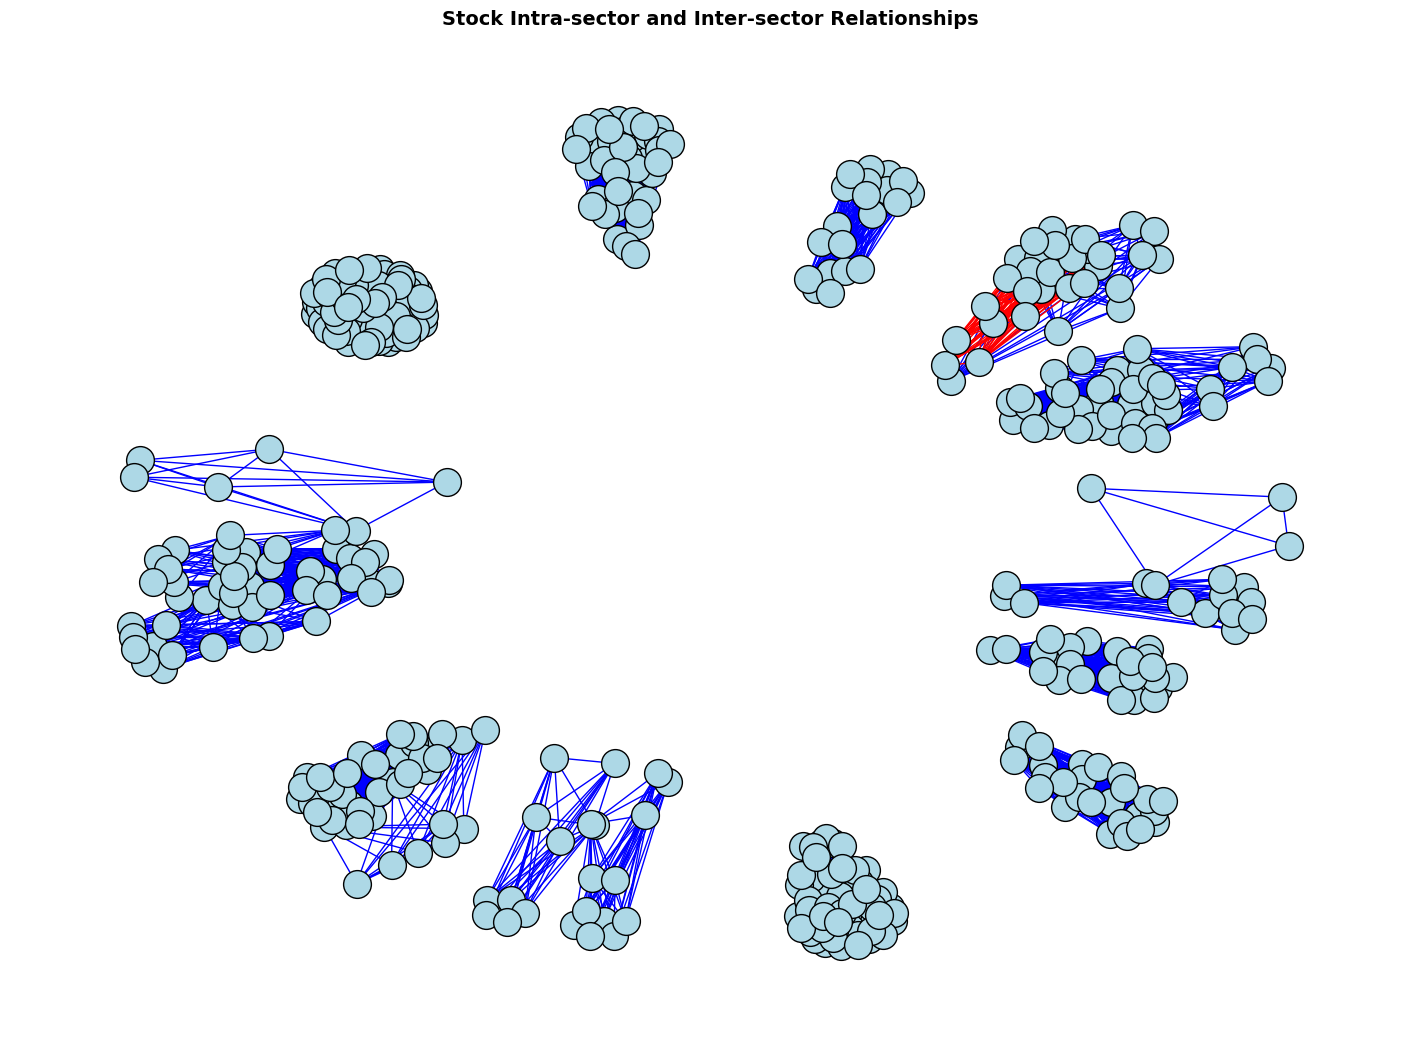

In [41]:
import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Dictionaries to store stock relationships
intra_sector_stock_2_stock = {}
sector_stocks = {}

file_path = 'Preprocessed_data'
for file in os.listdir(file_path):
    df = pd.read_csv(file_path + "/" + file)
    sector = df['Sector_Encoded'][0]
    if sector in sector_stocks:
        sector_stocks[sector].append(file[:-9])
    else:
        sector_stocks[sector] = [file[:-9]]
sector_stocks = {k: v for k, v in sector_stocks.items() if len(v) > 1}

name_matrix = {}
for same_sector_stocks in sector_stocks.values():
    for stock_key in same_sector_stocks:
        name_matrix.setdefault(stock_key, []).extend(
            [stock_value for stock_value in same_sector_stocks if stock_value != stock_key]
        )

intra_sector_stock_2_stock = name_matrix

inter_sector_matrix = {sector: [other_sector for other_sector in sector_stocks.keys() if sector != other_sector] for sector in sector_stocks.keys()}

# Create a graph
G = nx.Graph()

# Add intra-sector stock relationships
for stock, related_stocks in intra_sector_stock_2_stock.items():
    for related_stock in related_stocks:
        G.add_edge(stock, related_stock, color='blue')

# Add inter-sector relationships
for sector, related_sectors in inter_sector_matrix.items():
    for related_sector in related_sectors:
        G.add_edge(sector, related_sector, color='red')

# Draw the graph with better aesthetics
plt.figure(figsize=(14, 10))
edges = G.edges()
colors = [G[u][v]['color'] for u, v in edges]
pos = nx.spring_layout(G, k=0.3)  # Adjust spacing for clarity
nx.draw(G, pos, with_labels=False, edge_color=colors, node_size=400, node_color='lightblue', edgecolors='black')
plt.title("Stock Intra-sector and Inter-sector Relationships", fontsize=14, fontweight='bold')
plt.show()


In [42]:
import torch
import torch.nn as nn

class AttentiveGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, days_per_week=5):
        super(AttentiveGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.days_per_week = days_per_week
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        x: Tensor of shape (batch_size, total_days, input_dim)
        """
        batch_size, total_days, _ = x.shape

        # Number of weeks
        num_weeks = total_days // self.days_per_week

        # Reshape to (batch_size, num_weeks, days_per_week, input_dim)
        x_reshaped = x.view(batch_size, num_weeks, self.days_per_week, -1)

        weekly_embeddings = []

        for i in range(num_weeks):
            week_input = x_reshaped[:, i, :, :]  # Shape: (batch_size, days_per_week, input_dim)

            # GRU forward pass
            h_seq, _ = self.gru(week_input)  # (batch_size, days_per_week, hidden_dim)

            # Compute attention scores
            attn_weights = torch.tanh(self.attention(h_seq))  # (batch_size, days_per_week, 1)
            attn_weights = torch.softmax(attn_weights, dim=1)  # Normalize over time dimension

            # Compute weighted sum for weekly embeddings
            weekly_embedding = torch.sum(attn_weights * h_seq, dim=1)  # (batch_size, hidden_dim)

            weekly_embeddings.append(weekly_embedding)

        # Stack to get final shape (batch_size, num_weeks, hidden_dim)
        weekly_embeddings = torch.stack(weekly_embeddings, dim=1)

        return weekly_embeddings

# # Example usage
# batch_size = 403
# total_days = 30  # 30 days
# input_dim = 15  # Feature dimension per day

# model = AttentiveGRU(input_dim=input_dim, hidden_dim=64, days_per_week=5)
# dummy_input = torch.randn(batch_size, total_days, input_dim)  # Simulated daily features
# weekly_embeddings = model(dummy_input)  # Output shape: (batch_size, num_weeks, hidden_dim)

# print(weekly_embeddings.shape)  # Expected output: (403, 6, 64)

In [43]:
pip install torch torch_geometric

Note: you may need to restart the kernel to use updated packages.


In [44]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv

class StockGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=4, dropout=0.1):
        """
        Graph Attention Network (GAT) for modeling stock relationships within a sector.

        - in_dim: Input embedding size (e.g., 64)
        - hidden_dim: Size of hidden layer
        - out_dim: Output embedding size (final node representation)
        - heads: Number of attention heads
        - dropout: Dropout rate
        """
        super(StockGAT, self).__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_dim * heads, out_dim, heads=1, dropout=dropout)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index):
        """
        x: Tensor of stock embeddings (num_stocks, num_weeks, hidden_dim)
        edge_index: Graph connections (2, num_edges)
        """
        # Flatten the input tensor for GAT (num_stocks * num_weeks, hidden_dim)
        x = x.view(-1, x.size(-1)).to(device)  # Ensure x is on device
        edge_index = edge_index.to(device)  # Explicitly move edge_index
        # edge_index = edge_index.to(device)
        # Apply GAT layers
        x = self.gat1(x, edge_index)
        x = self.relu(x)
        x = self.gat2(x, edge_index)

        # Reshape the output back to (num_stocks, num_weeks, hidden_dim)
        x = x.view(-1, 6, x.size(-1))  # Assuming 6 weeks per stock

        return x

def process_batch(batch_stock_names, ai_batch, model, intra_sector_stock_2_stock):
    """
    Process a batch of stock names and their respective neighbors through the StockGAT model.

    - batch_stock_names: List of stock names in the current batch.
    - ai_batch: Tensor containing the embeddings of the stocks, shape (batch_size, num_weeks, hidden_dim).
    - model: The GAT model.
    - intra_sector_stock_2_stock: Dictionary mapping a stock to its neighbors.

    Returns:
    - A tensor of shape (batch_size, num_weeks, hidden_dim) representing the output embeddings.
    """
    # Create a list to store the edge connections for the entire batch
    edge_index_list = []

    for idx, name in enumerate(batch_stock_names):
        # Find neighbors of the current stock
        neighbour_names = intra_sector_stock_2_stock.get(name, [])

        # Add edges for the stock and its neighbors
        for neighbour in neighbour_names:
            neighbour_idx = batch_stock_names.index(neighbour)
            edge_index_list.append([idx, neighbour_idx])  # Add edge from the stock to its neighbor
            edge_index_list.append([neighbour_idx, idx])  # Add edge from the neighbor to the stock

    # Convert edge_index list to a tensor
    edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    edge_index = edge_index.to(device)
    # Pass the embeddings through the model
    gi_batch = model(ai_batch, edge_index)

    return gi_batch

# # Example usage
# batch_stock_names = ["AAPL", "GOOG", "AMZN", "MSFT"]
# ai_batch = torch.randn(4, 6, 64)  # Simulated embeddings for 4 stocks over 6 weeks
# intra_sector_stock_2_stock = {
#     "AAPL": ["GOOG", "MSFT"],
#     "GOOG": ["AAPL", "AMZN"],
#     "AMZN": ["GOOG", "MSFT"],
#     "MSFT": ["AAPL", "AMZN"]
# }
# model = StockGAT(in_dim=64, hidden_dim=64, out_dim=64)  # Example GAT model

# gi_batch = process_batch(batch_stock_names, ai_batch, model, intra_sector_stock_2_stock)
# # print(output_embeddings.shape)  # Expected shape: (4, 6, 64)

In [45]:
import torch
import torch.nn as nn

class LongTermAttentionBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, t=5):
        """
        A block that processes `ai_batch` (stock-specific embeddings) and `gi_batch` (sector-level embeddings)
        to compute the long-term trends using an attention mechanism.

        - input_dim: The dimension of the input embeddings (e.g., 64).
        - hidden_dim: The size of the hidden layer.
        - t: The look-back period (i.e., number of past weeks to consider for attention).
        """
        super(LongTermAttentionBlock, self).__init__()
        self.t = t
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Learnable parameters W and V for the attention mechanism
        self.W = nn.Parameter(torch.randn(input_dim, hidden_dim))
        self.V = nn.Parameter(torch.randn(hidden_dim, 1))

    def forward(self, ai_batch, gi_batch):
        """
        ai_batch: Tensor of shape (batch_size, t, input_dim) representing stock-specific embeddings.
        gi_batch: Tensor of shape (batch_size, t, input_dim) representing sector-level embeddings.

        Returns:
        - long_term_ai: Long-term embedding for stock-level trends (shape: (batch_size, hidden_dim)).
        - long_term_gi: Long-term embedding for sector-level trends (shape: (batch_size, hidden_dim)).
        """
        # Process the ai_batch (stock-specific embeddings)
        ai_attention_weights = self.compute_attention(ai_batch)  # (batch_size, t)

        # Expand the attention weights to shape (batch_size, t, 1) for broadcasting
        ai_attention_weights = ai_attention_weights.unsqueeze(-1)  # (batch_size, t, 1)

        # Compute weighted sum for ai_batch long-term embedding
        long_term_ai = torch.sum(ai_attention_weights * ai_batch, dim=1)  # (batch_size, input_dim)

        # Process the gi_batch (sector-level embeddings)
        gi_attention_weights = self.compute_attention(gi_batch)  # (batch_size, t)

        # Expand the attention weights to shape (batch_size, t, 1) for broadcasting
        gi_attention_weights = gi_attention_weights.unsqueeze(-1)  # (batch_size, t, 1)

        # Compute weighted sum for gi_batch long-term embedding
        long_term_gi = torch.sum(gi_attention_weights * gi_batch, dim=1)  # (batch_size, input_dim)

        return long_term_ai, long_term_gi

    def compute_attention(self, u_batch):
        """
        Compute attention weights using the formula:

        αj = exp(W^T * tanh(V * uj)) / sum(exp(W^T * tanh(V * uk))) for k in (i-t, ..., i-1)

        u_batch: Tensor of shape (batch_size, t, input_dim)
        """
        batch_size, t, input_dim = u_batch.shape

        # Apply the attention mechanism
        u_flat = u_batch.view(batch_size * t, input_dim)  # Flatten to shape (batch_size * t, input_dim)
        u_tanh = torch.tanh(torch.matmul(u_flat, self.W))  # (batch_size * t, hidden_dim)
        attention_scores = torch.matmul(u_tanh, self.V)  # (batch_size * t, 1)

        # Reshape attention_scores back to (batch_size, t)
        attention_scores = attention_scores.view(batch_size, t)  # (batch_size, t)

        # Apply softmax to get attention weights
        attention_weights = torch.softmax(attention_scores, dim=1)  # (batch_size, t)

        return attention_weights

# # Example usage
# batch_size = 407
# t = 6  # Look-back period for long-term embedding
# input_dim = 64
# hidden_dim = 64

# # Simulate the ai_batch (stock-specific) and gi_batch (sector-level) embeddings
# ai_batch = torch.randn(batch_size, t, input_dim)
# gi_batch = torch.randn(batch_size, t, input_dim)

# # Initialize the long-term attention block
# long_term_block = LongTermAttentionBlock(input_dim=input_dim, hidden_dim=hidden_dim, t=t)

# # Get the long-term embeddings for both stock-level and sector-level trends
# long_term_ai, long_term_gi = long_term_block(ai_batch, gi_batch)

# print("Long-term stock-level trend:", long_term_ai.shape)  # (batch_size, hidden_dim)
# print("Long-term sector-level trend:", long_term_gi.shape)  # (batch_size, hidden_dim)

In [46]:
import torch
import torch.nn as nn

class SectorEmbeddingBlock(nn.Module):
    def __init__(self, input_dim, num_sectors, t=5):
        """
        A block that processes `long_term_gi_batch` (sector-level embeddings) and computes the sector-level embeddings
        using max pooling.

        - input_dim: The dimension of the input embeddings (e.g., 64).
        - num_sectors: Number of sectors.
        - t: The look-back period (i.e., number of past weeks to consider for attention).
        """
        super(SectorEmbeddingBlock, self).__init__()
        self.t = t
        self.input_dim = input_dim
        self.num_sectors = num_sectors

    def forward(self, long_term_gi_batch, batch_names, sector_dict):
        """
        long_term_gi_batch: Tensor of shape (batch_size, input_dim) representing long-term sector embeddings.
        batch_names: List of stock names corresponding to each embedding in long_term_gi_batch.
        sector_dict: Dictionary mapping sector names to a list of stock names in that sector.

        Returns:
        - sector_embeddings: Tensor of shape (num_sectors, input_dim) representing the pooled
          embeddings for each sector.
        """
        # Initialize a tensor to store sector embeddings
        sector_embeddings = torch.zeros(self.num_sectors, self.input_dim).to(long_term_gi_batch.device)

        # Step 1: Max pooling across stocks within each sector
        for sector_idx, sector in enumerate(sector_dict.keys()):
            # Get the list of stock names in the current sector
            sector_stocks = sector_dict[sector]

            # Get the indices of stocks that belong to the current sector
            sector_indices = [i for i, name in enumerate(batch_names) if name in sector_stocks]

            # Extract the embeddings for the stocks in this sector
            sector_embeddings_tensor = long_term_gi_batch[sector_indices]  # (num_stocks_in_sector, input_dim)

            # Max pooling across the time dimension (axis=0)
            # Check if sector_embeddings_tensor is empty
            if sector_embeddings_tensor.shape[0] > 0:
                sector_embeddings[sector_idx] = torch.max(sector_embeddings_tensor, dim=0)[0]
            else:
                print(f"Empty tensor encountered for sector {sector_idx}")
                # Handle empty tensor case (e.g., skip or use a default embedding)
        return sector_embeddings

# # Example usage
# batch_size = 403
# t = 6  # Look-back period for long-term embedding
# input_dim = 64
# num_sectors = 5  # Number of sectors

# # Simulate the long_term_gi_batch (sector-level) embeddings
# long_term_gi_batch = torch.randn(batch_size, input_dim)
# # Simulate the stock names for each embedding
# batch_names = [f"stock_{i}" for i in range(batch_size)]

# # Simulate a sector dictionary with some dummy data
# sector_dict = {
#     "sector_1": [f"stock_{i}" for i in range(0, 100)],
#     "sector_2": [f"stock_{i}" for i in range(100, 200)],
#     "sector_3": [f"stock_{i}" for i in range(200, 300)],
#     "sector_4": [f"stock_{i}" for i in range(300, 400)],
#     "sector_5": [f"stock_{i}" for i in range(400, 403)]
# }

# # Initialize the sector embedding block
# sector_embedding_block = SectorEmbeddingBlock(input_dim=input_dim, num_sectors=num_sectors, t=t)

# # Get the sector-level embeddings
# sector_embeddings = sector_embedding_block(long_term_gi_batch, batch_names, sector_dict)

# print("Sector embeddings:", sector_embeddings.shape)  # (num_sectors, input_dim)

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data

class GATEmbeddingBlock(nn.Module):
    def __init__(self, input_dim, num_sectors, num_heads=1):
        """
        A block that takes sector embeddings and applies Graph Attention Network (GAT)

        - input_dim: The dimension of the input embeddings (e.g., 64).
        - num_sectors: Number of sectors.
        - num_heads: The number of attention heads for GAT.
        """
        super(GATEmbeddingBlock, self).__init__()

        self.num_heads = num_heads

        # GAT layer to process the sector embeddings
        self.gat = GATConv(input_dim, input_dim, heads=num_heads, concat=False)

    def forward(self, sector_embeddings, edge_index):
        """
        sector_embeddings: Tensor of shape (num_sectors, input_dim) representing the sector embeddings.
        edge_index: The graph structure (edge indices) for GAT.

        Returns:
        - learned_sector_embeddings: Tensor of shape (num_sectors, input_dim) representing the updated sector embeddings.
        """
        # Apply GAT
        learned_sector_embeddings = self.gat(sector_embeddings, edge_index)

        return learned_sector_embeddings

# # Example usage
# batch_size = 403
# t = 6  # Look-back period for long-term embedding
# input_dim = 64
# num_sectors = 5  # Number of sectors

# # Simulate the gi_batch (sector-level) embeddings
# gi_batch = torch.randn(batch_size, input_dim)
# # Simulate the stock names for each embedding
# batch_names = [f"stock_{i}" for i in range(batch_size)]

# # Simulate a sector dictionary with some dummy data
# sector_dict = {
#     "sector_1": [f"stock_{i}" for i in range(0, 100)],
#     "sector_2": [f"stock_{i}" for i in range(100, 200)],
#     "sector_3": [f"stock_{i}" for i in range(200, 300)],
#     "sector_4": [f"stock_{i}" for i in range(300, 400)],
#     "sector_5": [f"stock_{i}" for i in range(400, 403)]
# }

# # Initialize the sector embedding block
# sector_embedding_block = SectorEmbeddingBlock(input_dim=input_dim, num_sectors=num_sectors, t=t)

# # Get the sector-level embeddings
# sector_embeddings = sector_embedding_block(gi_batch, batch_names, sector_dict)

# # Construct a fully connected graph for sectors
# # Fully connected graph means every sector is connected to every other sector
# edge_index = torch.combinations(torch.arange(num_sectors), r=2).T  # (2, num_edges)

# # Initialize the GAT embedding block
# gat_embedding_block = GATEmbeddingBlock(input_dim=input_dim, num_sectors=num_sectors, num_heads=1)

# # Get the learned sector embeddings after applying GAT
# learned_sector_embeddings = gat_embedding_block(sector_embeddings, edge_index)

# print("Learned sector embeddings:", learned_sector_embeddings.shape)  # (num_sectors, input_dim)

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data

# Function to map stocks to sector embeddings and concatenate them
def map_stocks_to_sector_embeddings(batch_names, sector_dict, sector_embeddings, input_dim, stock_embeddings):
    """
    Map stocks in `batch_names` to their sector embeddings based on `sector_dict`.
    Then, concatenate stock-level, sector-level, and inter-sector embeddings.

    - batch_names: List of stock names in the order they appear in the embeddings.
    - sector_dict: Dictionary mapping sector names to a list of stock names in that sector.
    - sector_embeddings: Tensor of sector embeddings (num_sectors, input_dim).
    - input_dim: The embedding size (dimensionality of each embedding vector).

    Returns:
    - final_embeddings: Tensor containing the concatenated embeddings for each stock.
    """
    batch_size = len(batch_names)
    #print("batch size is", batch_size)
    sector_map = {name: sector for sector, names in sector_dict.items() for name in names}
    # Create a tensor to hold the mapped inter-sector embeddings for each stock
    mapped_inter_sector_embeddings = torch.ones(batch_size, input_dim, device=stock_embeddings.device)
    # Iterate over batch_names and assign sector embeddings
    for i, stock in enumerate(batch_names):
        if stock not in sector_map.keys():
            #print(stock," not in sector_map")
            continue
        sector_name = sector_map[stock]  # Find the sector of stock i
        sector_id = list(sector_dict.keys()).index(sector_name)  # Get sector index
        mapped_inter_sector_embeddings[i] = sector_embeddings[sector_id]  # Map sector embedding
    # print("Stcok embeddgins", stock_embeddings.shape)
    # print("mapped_inter_sector_embeddings shape",mapped_inter_sector_embeddings.shape)
    # Concatenate stock-level, sector-level, and inter-sector embeddings
    return mapped_inter_sector_embeddings

# Define the GAT block for sector embeddings processing
class GATEmbeddingBlock(nn.Module):
    def __init__(self, input_dim, num_sectors, num_heads=1):
        super(GATEmbeddingBlock, self).__init__()
        self.num_heads = num_heads
        self.gat = GATConv(input_dim, input_dim, heads=num_heads, concat=False)

    def forward(self, sector_embeddings, edge_index):
        learned_sector_embeddings = self.gat(sector_embeddings, edge_index)
        return learned_sector_embeddings

# Example usage
# batch_size = 407
# input_dim = 64
# num_sectors = 5  # Number of sectors
# t = 6  # Look-back period for long-term embedding

# # Simulate stock-level embeddings (gi_batch)
# stock_embeddings = torch.randn(batch_size, input_dim)  # (403, 64) for stock-specific
# # Simulate sector-level embeddings (sector_embeddings)
# sector_embeddings = torch.randn(num_sectors, input_dim)  # (5, 64) for sector-level embeddings

# # Simulate batch_names (list of stock names)
# batch_names = [f"stock_{i}" for i in range(batch_size)]

# # Simulate sector dictionary (mapping sectors to stock names)
# sector_dict = {
#     "sector_1": [f"stock_{i}" for i in range(0, 100)],
#     "sector_2": [f"stock_{i}" for i in range(100, 200)],
#     "sector_3": [f"stock_{i}" for i in range(200, 300)],
#     "sector_4": [f"stock_{i}" for i in range(300, 400)],
#     "sector_5": [f"stock_{i}" for i in range(400, 403)],
# }

# # Call the function to map stocks to sector embeddings and concatenate them
# final_embeddings = map_stocks_to_sector_embeddings(batch_names, sector_dict, sector_embeddings, input_dim)

# # Construct a fully connected graph for sectors
# edge_index = torch.combinations(torch.arange(num_sectors), r=2).T  # (2, num_edges)

# # Initialize the GAT embedding block
# gat_embedding_block = GATEmbeddingBlock(input_dim=input_dim, num_sectors=num_sectors, num_heads=1)

# # Get the learned sector embeddings after applying GAT
# learned_sector_embeddings = gat_embedding_block(sector_embeddings, edge_index)

# print("Final concatenated embeddings shape:", final_embeddings.shape)  # Should be (403, 128)
# print("Learned sector embeddings shape:", learned_sector_embeddings.shape)  # (num_sectors, input_dim)

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EmbeddingFusionLayer(nn.Module):
    def __init__(self, input_dim):
        """
        The Embedding Fusion Layer that combines short-term, intra-sector, and inter-sector embeddings.

        - input_dim: The dimensionality of the individual embeddings (e.g., 64).
        """
        super(EmbeddingFusionLayer, self).__init__()

        # Learnable weight matrix for fusion
        self.Wf = nn.Linear(input_dim * 3, input_dim)  # Input is concatenated, so 3 * input_dim

    def forward(self, short_term_embeddings, intra_sector_embeddings, inter_sector_embeddings_mapped):
        """
        Forward pass to combine the embeddings.

        - short_term_embeddings: Tensor of shape (batch_size, input_dim)
        - intra_sector_embeddings: Tensor of shape (batch_size, input_dim)
        - inter_sector_embeddings: Tensor of shape (batch_size, input_dim)

        Returns:
        - final_embeddings: Tensor of shape (batch_size, input_dim)
        """
        # Concatenate the embeddings along the feature dimension (axis 1)
        concatenated_embeddings = torch.cat(
            (short_term_embeddings, intra_sector_embeddings, inter_sector_embeddings_mapped), dim=1
        )  # Shape: (batch_size, input_dim*3)

        # Apply the fusion weight matrix (Wf) and ReLU activation
        final_embeddings = F.relu(self.Wf(concatenated_embeddings))

        return final_embeddings

# # Example usage
# batch_size = 403
# input_dim = 64

# # Simulate the individual embeddings (for simplicity)
# short_term_embeddings = torch.randn(batch_size, input_dim)  # (batch_size, input_dim)
# intra_sector_embeddings = torch.randn(batch_size, input_dim)  # (batch_size, input_dim)
# inter_sector_embeddings_mapped = torch.randn(batch_size, input_dim)  # (batch_size, input_dim)

# # Initialize the embedding fusion layer
# embedding_fusion_layer = EmbeddingFusionLayer(input_dim=input_dim)

# # Get the final fused embeddings
# final_embeddings = embedding_fusion_layer(short_term_embeddings, intra_sector_embeddings, inter_sector_embeddings_mapped)

# print("Final fused embeddings shape:", final_embeddings.shape)  # Should be (batch_size, input_dim)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

import torch
import torch.nn as nn

import torch
import torch.nn as nn

class CompleteStockModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_sectors, t=6, heads=4, dropout=0.1):
        super(CompleteStockModel, self).__init__()

        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)

        self.stock_gat = StockGAT(hidden_dim, hidden_dim, hidden_dim, heads, dropout)
        self.long_term_attention_block = LongTermAttentionBlock(hidden_dim, hidden_dim, t)
        self.sector_embedding_block = SectorEmbeddingBlock(hidden_dim, num_sectors, t)
        self.gat_embedding_block = GATEmbeddingBlock(hidden_dim, num_sectors, heads)
        self.embedding_fusion_layer = EmbeddingFusionLayer(hidden_dim)

        # Loss function parameters
        self.e1 = nn.Parameter(torch.randn(hidden_dim))  # Hidden vector for return ratio
        self.b1 = nn.Parameter(torch.zeros(1))  # Bias for return ratio

        self.e2 = nn.Parameter(torch.randn(hidden_dim))  # Hidden vector for stock movement
        self.b2 = nn.Parameter(torch.zeros(1))  # Bias for stock movement

    def forward(self, x, batch_stock_names, intra_sector_stock_2_stock, sector_dict):
        # Compute weekly embeddings using LSTM
        h0 = torch.zeros(1, x.size(0), self.hidden_dim).to(x.device)  # Initial hidden state
        c0 = torch.zeros(1, x.size(0), self.hidden_dim).to(x.device)  # Initial cell state
        lstm_out, _ = self.lstm(x, (h0, c0))

        # Take the last time step output
        weekly_embeddings = lstm_out[:, -1, :]

        # Compute GAT embeddings
        gi_batch = process_batch(batch_stock_names, weekly_embeddings, self.stock_gat, intra_sector_stock_2_stock)

        # Compute long-term trends
        long_term_ai, long_term_gi = self.long_term_attention_block(weekly_embeddings, gi_batch)

        # Calculate sector embeddings
        sector_embeddings = self.sector_embedding_block(long_term_gi, batch_stock_names, sector_dict)

        # Apply GAT to sector embeddings
        learned_sector_embeddings = self.gat_embedding_block(sector_embeddings, self.create_edge_index(sector_dict))

        # Map stocks to sector embeddings
        final_stock_embeddings = map_stocks_to_sector_embeddings(
            batch_stock_names, sector_dict, learned_sector_embeddings, self.hidden_dim, long_term_gi
        )

        # Fuse the embeddings
        final_embeddings = self.embedding_fusion_layer(long_term_ai, long_term_gi, final_stock_embeddings)

        # Compute return and movement predictions
        y_return = torch.matmul(final_embeddings, self.e1) + self.b1
        y_move = torch.sigmoid(torch.matmul(final_embeddings, self.e2) + self.b2)

        return final_embeddings, y_return, y_move

    def create_edge_index(self, sector_dict):
        """
        Creates an edge index for the GAT embedding block based on the sectors.
        """
        edge_index_list = []
        sector_names = list(sector_dict.keys())

        for i, sector in enumerate(sector_names):
            for j in range(i + 1, len(sector_names)):  # Connect all sectors to each other
                edge_index_list.append([i, j])
                edge_index_list.append([j, i])

        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        return edge_index

class LossFunction(nn.Module):
    def __init__(self, lambda_reg=0.01, delta=0.5):
        super(LossFunction, self).__init__()
        self.lambda_reg = lambda_reg  # Regularization parameter
        self.delta = delta  # Weighting factor for loss components

    def compute_rank_loss(self, y_return, y_true_return):
        """
        Compute pairwise ranking loss.
        """
        y_diff_pred = y_return.unsqueeze(1) - y_return.unsqueeze(0)
        y_diff_true = y_true_return.unsqueeze(1) - y_true_return.unsqueeze(0)
        mask = (y_diff_true > 0).float()
        Lrank = torch.sum(F.relu(-y_diff_pred * y_diff_true) * mask) / (torch.sum(mask) + 1e-8)
        return Lrank

    def compute_move_loss(self, y_move, y_true_move):
        """
        Compute cross-entropy loss for stock movement.
        """
        return F.binary_cross_entropy(y_move, y_true_move)

    def forward(self, y_return, y_move, y_true_return, y_true_move, model):
        """
        Compute total loss.
        """
        Lrank = self.compute_rank_loss(y_return, y_true_return)
        Lmove = self.compute_move_loss(y_move, y_true_move)
        L2_reg = torch.norm(model.e1) ** 2 + torch.norm(model.e2) ** 2
        total_loss = (1 - self.delta) * Lrank + self.delta * Lmove + self.lambda_reg * L2_reg
        return total_loss


In [52]:
model = CompleteStockModel(input_dim=15, hidden_dim=64, num_sectors=23).to(device)

data_dir = 'Preprocessed_data'  # Directory containing 403 CSV files
window_size = 30  # Number of timesteps per batch for each stock

# Initialize the data loader
data_loader = StockDataLoader(data_dir, window_size)

# Create an iterator
data_iter = iter(data_loader)

x, stock_names, y1, y2 = next(data_iter)

# Move tensors to the device
x = x.to(device)
y1, y2 = y1.to(device), y2.to(device)

# If intra_sector_stock_2_stock and sector_stocks are tensors, move them too
#intra_sector_stock_2_stock = intra_sector_stock_2_stock.to(device)
#sector_stocks = {key: val.to(device) for key, val in sector_stocks.items()}  # If sector_stocks is a dictionary of tensors
#print(sector_stocks)
# Pass everything to the model
output = model(x, stock_names, intra_sector_stock_2_stock, sector_stocks)
print("output shape", output.device)

output shape cuda:0


In [53]:
import torch.optim as optim

loss_fn = LossFunction(64)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [54]:
import torch
import pandas as pd
import numpy as np

def Precision(test_y, pred_y, k=5):
    predict = pd.DataFrame({'pred_y': pred_y, 'y': test_y})
    predict1 = predict.sort_values("pred_y", ascending=False)
    predict2 = predict.sort_values("y", ascending=False)
    correct = len(set(predict1.index[:k]) & set(predict2.index[:k]))
    print(f"Top {k} predicted indices: {list(predict1.index[:k])}")
    print(f"Top {k} actual indices: {list(predict2.index[:k])}")
    return correct / k

def IRR(test_y, pred_y, k=5):
    predict = pd.DataFrame({'pred_y': pred_y, 'y': test_y})
    predict1 = predict.sort_values("pred_y", ascending=False)
    predict2 = predict.sort_values("y", ascending=False)
    return sum(predict2["y"][:k]) - sum(predict1["y"][:k])

def Acc(test_y, pred_y):
    test_y = np.ravel(test_y)
    pred_y = np.ravel(pred_y)
    pred_y = (pred_y > 0) * 1
    return np.mean(test_y == pred_y)

def compute_mrr(predicted_ranks, actual_ranks, top_k=5):
    top_k_predicted_stocks = list(predicted_ranks.keys())[:top_k]
    mrr_top_k = sum(1 / actual_ranks[stock] for stock in top_k_predicted_stocks if stock in actual_ranks) / top_k
    return mrr_top_k

In [ ]:
import torch
import pandas as pd
import numpy as np

def Precision(test_y, pred_y, k=5):
    predict = pd.DataFrame({'pred_y': pred_y, 'y': test_y})
    predict1 = predict.sort_values("pred_y", ascending=False)
    predict2 = predict.sort_values("y", ascending=False)
    correct = len(set(predict1.index[:k]) & set(predict2.index[:k]))
    return correct / k

def IRR(test_y, pred_y, k=5):
    predict = pd.DataFrame({'pred_y': pred_y, 'y': test_y})
    predict1 = predict.sort_values("pred_y", ascending=False)
    predict2 = predict.sort_values("y", ascending=False)
    return sum(predict2["y"][:k]) - sum(predict1["y"][:k])

def Acc(test_y, pred_y):
    test_y = np.ravel(test_y)
    pred_y = np.ravel(pred_y)
    pred_y = (pred_y > 0) * 1
    return np.mean(test_y == pred_y)

def compute_mrr(predicted_ranks, actual_ranks, top_k=5):
    top_k_predicted_stocks = list(predicted_ranks.keys())[:top_k]
    mrr_top_k = sum(1 / actual_ranks[stock] for stock in top_k_predicted_stocks if stock in actual_ranks) / top_k
    return mrr_top_k

# Training loop
num_epochs = 6
max_batches = 1
top_k_list = [5, 10, 20]
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    batch_count = 0
    stock_return_dict = {}
    stock_true_return_dict = {}

    for batch_idx, batch in enumerate(data_loader):
        if batch_idx >= max_batches:
            print("Reached max batch limit, stopping loop")
            break
        
        batch_count += 1
        x, stock_names, y_true_move, y_true_return = batch
        x, y_true_move, y_true_return = x.to(device), y_true_move.to(device), y_true_return.to(device)
        optimizer.zero_grad()
        output, y_return, y_move = model(x, stock_names, intra_sector_stock_2_stock, sector_stocks)
        loss = loss_fn(output, y_true_return, y_true_move)

        if torch.isnan(loss):
            print(f"NaN detected in loss at Epoch {epoch + 1}, Batch {batch_idx + 1}. Stopping training.")
            break

        loss.backward()
        optimizer.step()
        running_loss += loss.detach().cpu().item()

        for i, stock in enumerate(stock_names):
            stock_return_dict[stock] = y_return[i].detach().cpu().numpy()
            stock_true_return_dict[stock] = y_true_return[i].detach().cpu().numpy()

    if batch_count == 0:
        print("No batches processed, exiting training.")
        exit()

    avg_loss = running_loss / batch_count
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

    sorted_predicted = sorted(stock_return_dict.items(), key=lambda item: item[1], reverse=True)
    sorted_actual = sorted(stock_true_return_dict.items(), key=lambda item: item[1], reverse=True)

    predicted_ranks = {stock: rank + 1 for rank, (stock, _) in enumerate(sorted_predicted)}
    actual_ranks = {stock: rank + 1 for rank, (stock, _) in enumerate(sorted_actual)}




Reached max batch limit, stopping loop
Epoch [1/50], Loss: 1.5958
Reached max batch limit, stopping loop
Epoch [2/50], Loss: 1.5951
Reached max batch limit, stopping loop
Epoch [3/50], Loss: 1.5946
Reached max batch limit, stopping loop
Epoch [4/50], Loss: 1.5969
Reached max batch limit, stopping loop
Epoch [5/50], Loss: 1.5957
Reached max batch limit, stopping loop
Epoch [6/50], Loss: 1.5944
Reached max batch limit, stopping loop
Epoch [7/50], Loss: 1.5946
Reached max batch limit, stopping loop
Epoch [8/50], Loss: 1.5954
Reached max batch limit, stopping loop
Epoch [9/50], Loss: 1.5944
Reached max batch limit, stopping loop
Epoch [10/50], Loss: 1.5964
Reached max batch limit, stopping loop
Epoch [11/50], Loss: 1.5947
Reached max batch limit, stopping loop
Epoch [12/50], Loss: 1.5964
Reached max batch limit, stopping loop
Epoch [13/50], Loss: 1.5973
Reached max batch limit, stopping loop
Epoch [14/50], Loss: 1.5981
Reached max batch limit, stopping loop
Epoch [15/50], Loss: 1.5961
Reac

In [ ]:
#### IF THAT TRAINING LOOP DOESNT RUN THEN TRY THIS IF THIS ALSO  DOESNT RUN THEN TRY FIXING ONE OR THE OTHER IG :)
import torch
import pandas as pd
import numpy as np

# Precision function
def Precision(test_y, pred_y, k=5):
    predict = pd.DataFrame({'pred_y': pred_y, 'y': test_y})
    predict = predict.sort_values("pred_y", ascending=False).reset_index(drop=True)
    correct = len(set(predict.index[:k]) & set(predict.sort_values("y", ascending=False).index[:k]))
    return correct / k

# IRR function
def IRR(test_y, pred_y, k=5):
    predict = pd.DataFrame({'pred_y': pred_y, 'y': test_y})
    predict = predict.sort_values("pred_y", ascending=False).reset_index(drop=True)
    actual_sorted = predict.sort_values("y", ascending=False).reset_index(drop=True)
    return sum(actual_sorted["y"][:k]) - sum(predict["y"][:k])

# Accuracy function
def Acc(test_y, pred_y, threshold=0.5):
    test_y = np.ravel(test_y)
    pred_y = np.ravel(pred_y)
    pred_y = (pred_y > threshold) * 1
    return np.mean(test_y == pred_y)

# MRR computation
def compute_mrr(predicted_ranks, actual_ranks, top_k=5):
    top_k_predicted_stocks = list(predicted_ranks.keys())[:top_k]
    mrr_top_k = sum(1 / actual_ranks[stock] for stock in top_k_predicted_stocks if stock in actual_ranks) / top_k
    return mrr_top_k

# Training loop
num_epochs = 6
max_batches = 1
top_k_list = [5, 10, 20]

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    batch_count = 0
    stock_return_dict = {}
    stock_true_return_dict = {}

    for batch_idx, batch in enumerate(data_loader):
        if batch_idx >= max_batches:
            print("Reached max batch limit, stopping loop")
            break
        
        batch_count += 1
        x, stock_names, y_true_move, y_true_return = batch
        x, y_true_move, y_true_return = x.to(device), y_true_move.to(device), y_true_return.to(device)

        optimizer.zero_grad()
        
        # Forward pass
        try:
            output, y_return, y_move = model(x, stock_names, intra_sector_stock_2_stock, sector_stocks)
            loss = loss_fn(y_return, y_true_return, y_move, y_true_move)  # Ensure correct inputs to loss_fn
        except Exception as e:
            print(f"Error in model forward pass: {e}")
            continue  # Skip this batch
        
        if torch.isnan(loss).any():
            print(f"NaN detected in loss at Epoch {epoch + 1}, Batch {batch_idx + 1}. Skipping batch.")
            continue  # Skip this batch instead of stopping training

        loss.backward()
        optimizer.step()
        running_loss += loss.detach().cpu().item()

        for i, stock in enumerate(stock_names):
            stock_return_dict[stock] = y_return[i].detach().cpu().numpy()
            stock_true_return_dict[stock] = y_true_return[i].detach().cpu().numpy()

    if batch_count == 0:
        print("No batches processed, exiting training.")
        break  # Use break instead of exit() to avoid stopping the entire script

    avg_loss = running_loss / batch_count
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

    # Rank sorting
    sorted_predicted = sorted(stock_return_dict.items(), key=lambda item: item[1], reverse=True)
    sorted_actual = sorted(stock_true_return_dict.items(), key=lambda item: item[1], reverse=True)

    predicted_ranks = {stock: rank + 1 for rank, (stock, _) in enumerate(sorted_predicted)}
    actual_ranks = {stock: rank + 1 for rank, (stock, _) in enumerate(sorted_actual)}

In [74]:
# Remove company "ABREL" from both dictionaries if it exists
if "ABREL" in stock_return_dict:
    del stock_return_dict["ABREL"]
if "ABREL" in stock_true_return_dict:
    del stock_true_return_dict["ABREL"]

# Recompute rankings after removing "ABREL"
sorted_predicted = sorted(stock_return_dict.items(), key=lambda item: item[1], reverse=True)
sorted_actual = sorted(stock_true_return_dict.items(), key=lambda item: item[1], reverse=True)

predicted_ranks = {stock: rank + 1 for rank, (stock, _) in enumerate(sorted_predicted)}
actual_ranks = {stock: rank + 1 for rank, (stock, _) in enumerate(sorted_actual)}


In [75]:

for k in top_k_list:
    mrr = compute_mrr(predicted_ranks, actual_ranks, top_k=k)
    precision = Precision(list(stock_true_return_dict.values()), list(stock_return_dict.values()), k=k)
    irr = IRR(list(stock_true_return_dict.values()), list(stock_return_dict.values()), k=k)
    print(f"MRR@{k}: {mrr:.4f}, Precision@{k}: {precision:.4f}, IRR@{k}: {irr:.4f}")

accuracy = Acc(list(stock_true_return_dict.values()), list(stock_return_dict.values()))
print(f"Accuracy: {accuracy:.4f}")

for k in top_k_list:
    print(f"Top {k} Companies based on Predicted Returns:")
    for rank, (stock, return_value) in enumerate(sorted_predicted[:k], start=1):
        print(f"Rank {rank}: Stock {stock}, Predicted Return: {return_value:.4f}")
    print("\n\n")

MRR@5: 0.0559, Precision@5: 0.2000, IRR@5: 0.3111
MRR@10: 0.0312, Precision@10: 0.1000, IRR@10: 0.6538
MRR@20: 0.0204, Precision@20: 0.0500, IRR@20: 1.1407
Accuracy: 0.0000
Top 5 Companies based on Predicted Returns:
Rank 1: Stock IDEA, Predicted Return: 1.8662
Rank 2: Stock TANLA, Predicted Return: 1.4487
Rank 3: Stock HDFCBANK, Predicted Return: 1.4321
Rank 4: Stock IFCI, Predicted Return: 1.4012
Rank 5: Stock ALOKINDS, Predicted Return: 1.3982



Top 10 Companies based on Predicted Returns:
Rank 1: Stock IDEA, Predicted Return: 1.8662
Rank 2: Stock TANLA, Predicted Return: 1.4487
Rank 3: Stock HDFCBANK, Predicted Return: 1.4321
Rank 4: Stock IFCI, Predicted Return: 1.4012
Rank 5: Stock ALOKINDS, Predicted Return: 1.3982
Rank 6: Stock EASEMYTRIP, Predicted Return: 1.3594
Rank 7: Stock GRSE, Predicted Return: 1.3416
Rank 8: Stock JPPOWER, Predicted Return: 1.3371
Rank 9: Stock GNFC, Predicted Return: 1.3308
Rank 10: Stock MOTILALOFS, Predicted Return: 1.3113



Top 20 Companies based 